<a href="https://colab.research.google.com/github/TechWithEva/Telecom-X-Challenge3-G9/blob/main/TelecomX_Challenge3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TELECOM X

# Integración de Orígenes de Datos e importación de librerías

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import io

url=('https://raw.githubusercontent.com/TechWithEva/Telecom-X-Challenge3-G9/refs/heads/main/rawdata/base_ClientesTX.csv')
response=requests.get(url)
base_ClientesTX = pd.read_csv( io.StringIO(response.text))
ClientesTXBase = base_ClientesTX.copy()

# Análisis

## Depurar Data
---
Excluir valores que podrían afectar el modelo, o actualizar aquellos que requieren tipado distinto

In [3]:
ClientesTXBase['churn']=ClientesTXBase['churn'].astype(int)
ClientesTXBase.drop(columns=['clienteID'], inplace=True)
ClientesTXBase['genero']=ClientesTXBase['genero'].replace({'F':0,'M':1})
ClientesTXBase['genero'] = ClientesTXBase['genero'].astype(int)

/tmp/ipykernel_500/4070376485.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ClientesTXBase['genero']=ClientesTXBase['genero'].replace({'F':0,'M':1})


In [4]:
ClientesTXBase.info()
ClientesTXBase.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   churn                               7267 non-null   int64  
 1   genero                              7267 non-null   int64  
 2   tercera_edad                        7267 non-null   bool   
 3   tiene_pareja                        7267 non-null   bool   
 4   tiene_dependientes                  7267 non-null   bool   
 5   antiguedadContrato_Meses            7267 non-null   int64  
 6   telefono_suscripcion                7267 non-null   bool   
 7   telefono_lineas_multiples           7267 non-null   bool   
 8   internet_suscripcion                7267 non-null   bool   
 9   seguridadOnline_suscripcion         7267 non-null   bool   
 10  backupOnline_suscripcion            7267 non-null   bool   
 11  proteccionDispositivos_suscripcion  7267 no

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
churn,7267.0,NaN,NaN,NaN,0.288014,0.452869,0.0,0.0,0.0,1.0,1.0
genero,7267.0,NaN,NaN,NaN,0.505711,0.500002,0.0,0.0,1.0,1.0,1.0
tercera_edad,7267,2,False,6085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tiene_pareja,7267,2,False,3749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tiene_dependientes,7267,2,False,5086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
antiguedadContrato_Meses,7267.0,NaN,NaN,NaN,32.346498,24.571773,0.0,9.0,29.0,55.0,72.0
telefono_suscripcion,7267,2,True,6560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telefono_lineas_multiples,7267,2,False,4202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_suscripcion,7267,2,True,5686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seguridadOnline_suscripcion,7267,2,False,5189,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
for column in ClientesTXBase.columns:
  print(f'{column}:{ClientesTXBase[column].unique()}')



churn:[0 1]
genero:[0 1]
tercera_edad:[False  True]
tiene_pareja:[ True False]
tiene_dependientes:[ True False]
antiguedadContrato_Meses:[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
telefono_suscripcion:[ True False]
telefono_lineas_multiples:[False  True]
internet_suscripcion:[ True False]
seguridadOnline_suscripcion:[False  True]
backupOnline_suscripcion:[ True False]
proteccionDispositivos_suscripcion:[False  True]
soporteTecnico_suscripcion:[ True False]
tvDigital_suscripcion:[ True False]
peliculasDigitales_suscripcion:[False  True]
tipo_contrato:['ANUAL' 'MENSUAL' 'BIENAL']
factura_digital:[ True False]
metodo_pago:['CHEQUE POSTAL' 'CHEQUE ELECTRONICO' 'TARJETA CREDITO'
 'TRANSFERENCIA BANCARIA']
cargos_mensuales:[65.6  59.9  73.9  ... 91.75 68.8  67.85]
cargos_totales:[ 593.3   542.4   280.85 ...  742.9

## Matriz de correlación
---

### Correlación de variables númericas

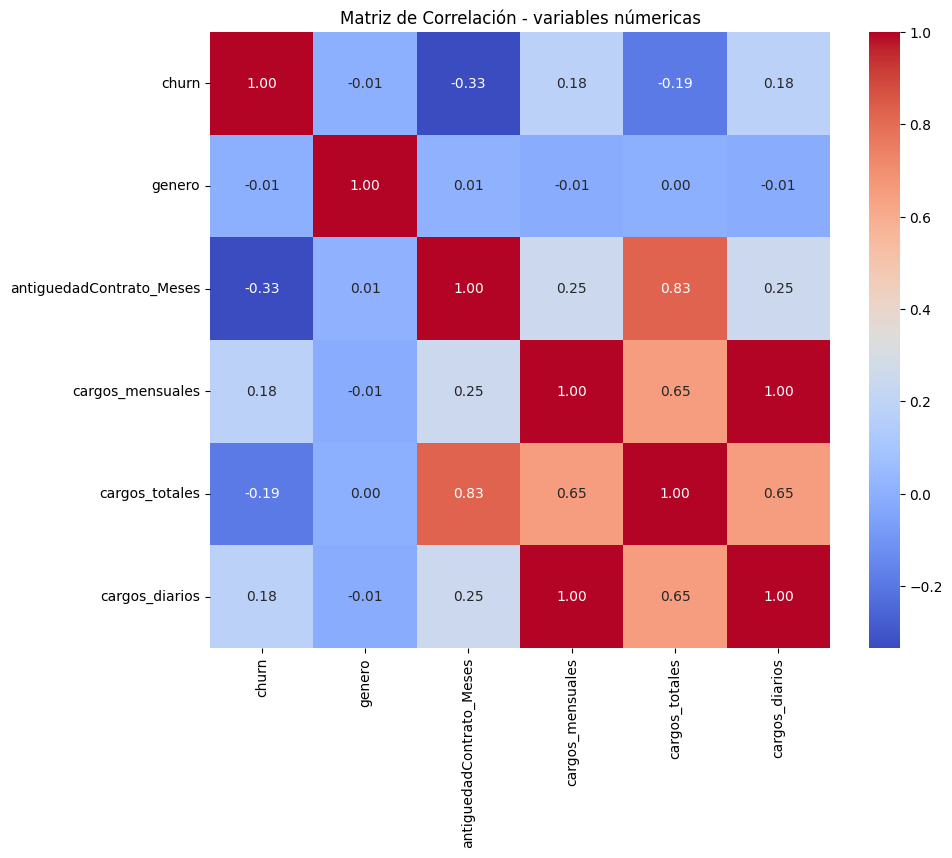

In [6]:
variablesNumericas=ClientesTXBase.select_dtypes(include=[np.number])
matriz_correlacion = variablesNumericas.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación - variables númericas')
plt.show()

###Depuración de variables en base a análisis de correlación númerica

In [7]:
ClientesTXBase.drop(columns=['cargos_diarios','cargos_totales'], inplace=True)

### Análisis de Churn por categoría (variables categóricas)

In [8]:
'''columns_categorical = ClientesTXBase.select_dtypes(include=['object','bool']).columns
columns_categorical

for column in columns_categorical:
  print(f'\n Análisis de Variables: {column}')
  display(pd.crosstab(ClientesTXBase[column], ClientesTXBase['churn'], normalize='index')*100)'''



"columns_categorical = ClientesTXBase.select_dtypes(include=['object','bool']).columns\ncolumns_categorical\n\nfor column in columns_categorical:\n  print(f'\n Análisis de Variables: {column}')\n  display(pd.crosstab(ClientesTXBase[column], ClientesTXBase['churn'], normalize='index')*100)"

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

df_rank = ClientesTXBase.copy()
columns_categorical = df_rank.select_dtypes(include=['object','bool']).columns
le = LabelEncoder()
for column in columns_categorical:
    df_rank[column] = le.fit_transform(df_rank[column])

xCat = df_rank[columns_categorical]
yCat = df_rank['churn']

chi2_scores, p_values = chi2(xCat, yCat)
chi_df = pd.DataFrame({'Variable':columns_categorical,'chi2_Score':chi2_scores,'p_value': p_values})
chi_df = chi_df.sort_values(by='chi2_Score', ascending=False)
chi_df


,Variable,chi2_Score,p_value
14,metodo_pago,440.553562,8.202947e-98
12,tipo_contrato,367.226879,7.516137e-82
15,pago_automatico,166.448214,4.415286e-38
6,seguridadOnline_suscripcion,140.282859,2.308657e-32
9,soporteTecnico_suscripcion,129.070531,6.545079e-30
0,tercera_edad,127.169623,1.705553e-29
2,tiene_dependientes,119.476204,8.237765e-28
13,factura_digital,100.704259,1.067957e-23
17,ambasSuscripciones,85.800085,1.990776e-20
1,tiene_pareja,72.207255,1.937421e-17


In [10]:
#variables a eliminar
clientesTXBase = ClientesTXBase.drop(columns='telefono_suscripcion')

##Preparando dataset para modelado ML

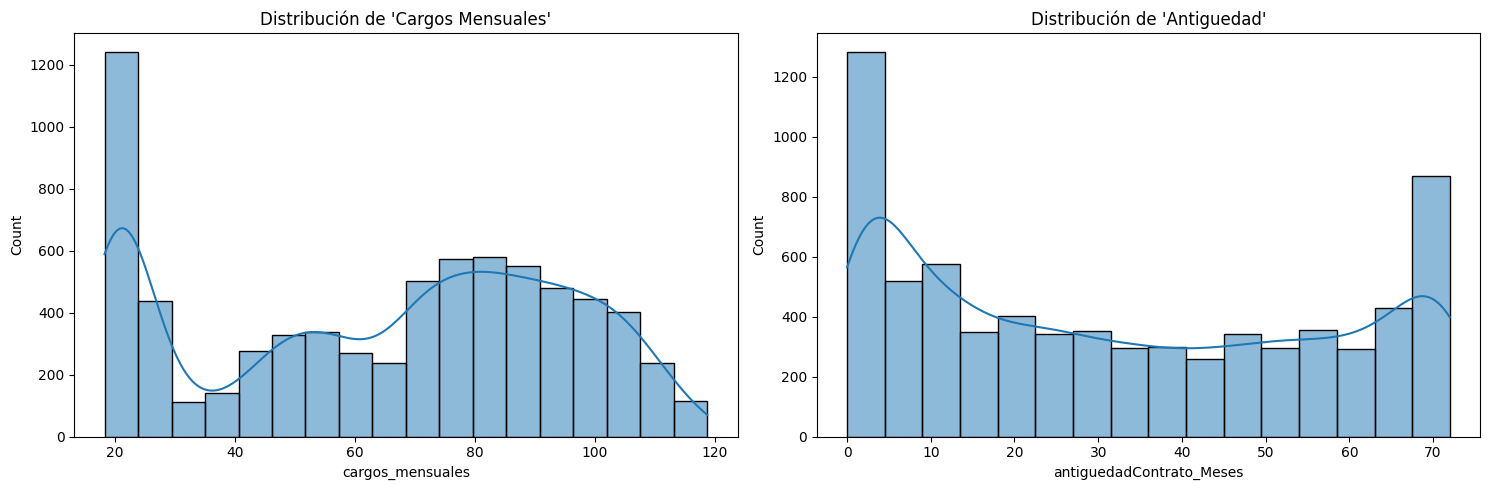

In [11]:
# Graficamos la distribución de los valores de las variables numéricas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
sns.histplot(data=ClientesTXBase, x="cargos_mensuales", kde=True, ax=axes[0])
axes[0].set_title("Distribución de 'Cargos Mensuales'")
sns.histplot(data=ClientesTXBase, x='antiguedadContrato_Meses', kde=True, ax=axes[1])
axes[1].set_title("Distribución de 'Antiguedad'")
plt.tight_layout()
plt.show()

In [12]:
X = ClientesTXBase.drop(columns='churn',axis=1)
y = clientesTXBase['churn']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )


#X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [13]:
from sklearn.preprocessing import MinMaxScaler
col_numeric = X_train.select_dtypes(include=[np.number]).columns
scaler = MinMaxScaler()

# variables X de entrenamiento y prueba Normalizadas
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

# Normalización x conjunto de entrenamiento y prueba previo
X_train_norm[col_numeric] = scaler.fit_transform(X_train[col_numeric])
X_test_norm[col_numeric] = scaler.transform(X_test[col_numeric])

#testing
#X_train_norm[col_numeric].describe()

In [14]:
# Aplicar One-Hot Encoding entreno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en teste
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que entreno y teste tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

y_train.value_counts(normalize=True) * 100

,proportion
churn,
0,71.202477
1,28.797523


# Modelos Predictivos

## Regresión Logística

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

Regresion logistica
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.65      0.53      0.58       419

    accuracy                           0.78      1454
   macro avg       0.74      0.71      0.72      1454
weighted avg       0.77      0.78      0.77      1454



## Ramdon Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.81      0.86      0.84      1035
           1       0.60      0.49      0.54       419

    accuracy                           0.76      1454
   macro avg       0.70      0.68      0.69      1454
weighted avg       0.75      0.76      0.75      1454



## Tree Model

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Classifier")
print(classification_report(y_test, y_pred_dt))

# Gradient Boosting Classifier
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train, y_train)
y_pred_gbc = gbc_model.predict(X_test)

print("\nGradient Boosting Classifier")
print(classification_report(y_test, y_pred_gbc))

Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1035
           1       0.50      0.53      0.52       419

    accuracy                           0.71      1454
   macro avg       0.66      0.66      0.66      1454
weighted avg       0.72      0.71      0.72      1454


Gradient Boosting Classifier
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.65      0.53      0.58       419

    accuracy                           0.78      1454
   macro avg       0.74      0.71      0.72      1454
weighted avg       0.77      0.78      0.77      1454



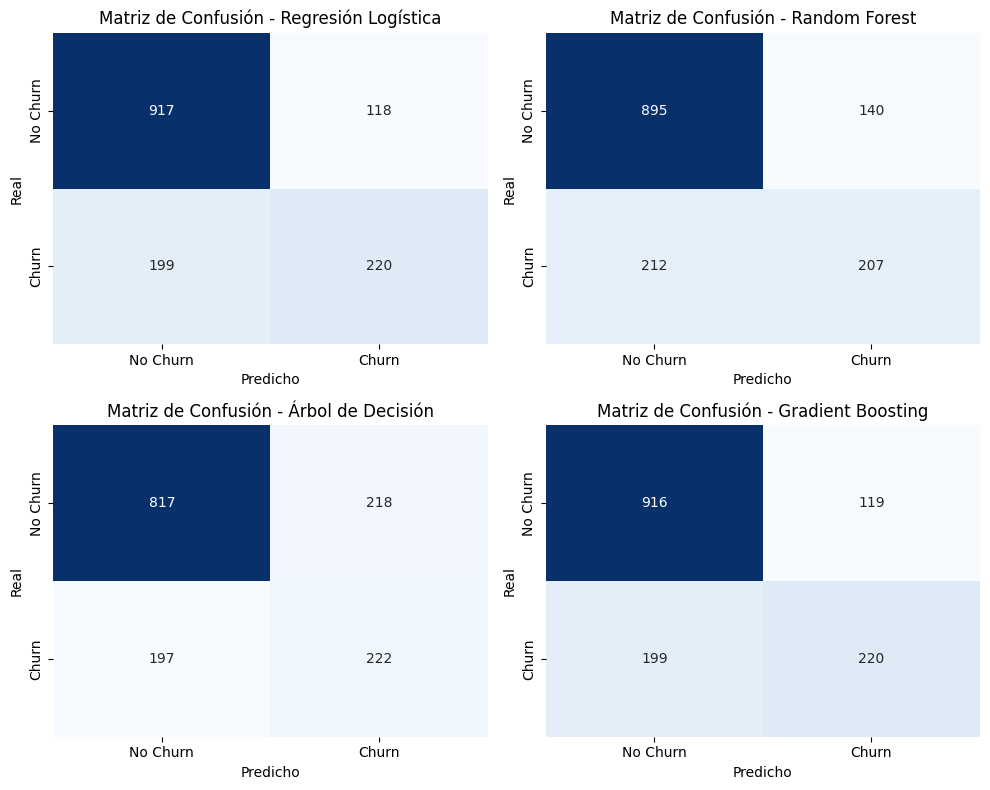

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

models = {
    'Regresión Logística': y_pred_log_normal,
    'Random Forest': y_pred_rf,
    'Árbol de Decisión': y_pred_dt,
    'Gradient Boosting': y_pred_gbc
}

for i, (model_name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'], ax=axes[i])
    axes[i].set_title(f'Matriz de Confusión - {model_name}')
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

## Evaluación de los Modelos

In [19]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# --- Regresión Logística ---
acc_log = accuracy_score(y_test, y_pred_log_normal)
f1_log_churn = f1_score(y_test, y_pred_log_normal, pos_label=1)

# --- Random Forest ---
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf_churn = f1_score(y_test, y_pred_rf, pos_label=1)

# --- Decision Tree ---
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt_churn = f1_score(y_test, y_pred_dt, pos_label=1)

# --- Gradient Boosting Classifier ---
acc_gbc = accuracy_score(y_test, y_pred_gbc)
f1_gbc_churn = f1_score(y_test, y_pred_gbc, pos_label=1)


model_performance = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'Gradient Boosting Classifier'],
    'Accuracy': [acc_log, acc_rf, acc_dt, acc_gbc],
    'F1-score (Churn Class)': [f1_log_churn, f1_rf_churn, f1_dt_churn, f1_gbc_churn]
})

# Ordenar por F1-score de Churn Class
model_performance_sorted = model_performance.sort_values(by=['F1-score (Churn Class)', 'Accuracy'], ascending=False)

display(model_performance_sorted)

# Identify the champion model
champion_model_name = model_performance_sorted.iloc[0]['Model']
print(f"\nThe champion model is: {champion_model_name}")


,Model,Accuracy,F1-score (Churn Class)
0,Logistic Regression,0.781981,0.581242
3,Gradient Boosting Classifier,0.781293,0.580475
1,Random Forest,0.757909,0.540470
2,Decision Tree,0.714580,0.516880



The champion model is: Logistic Regression


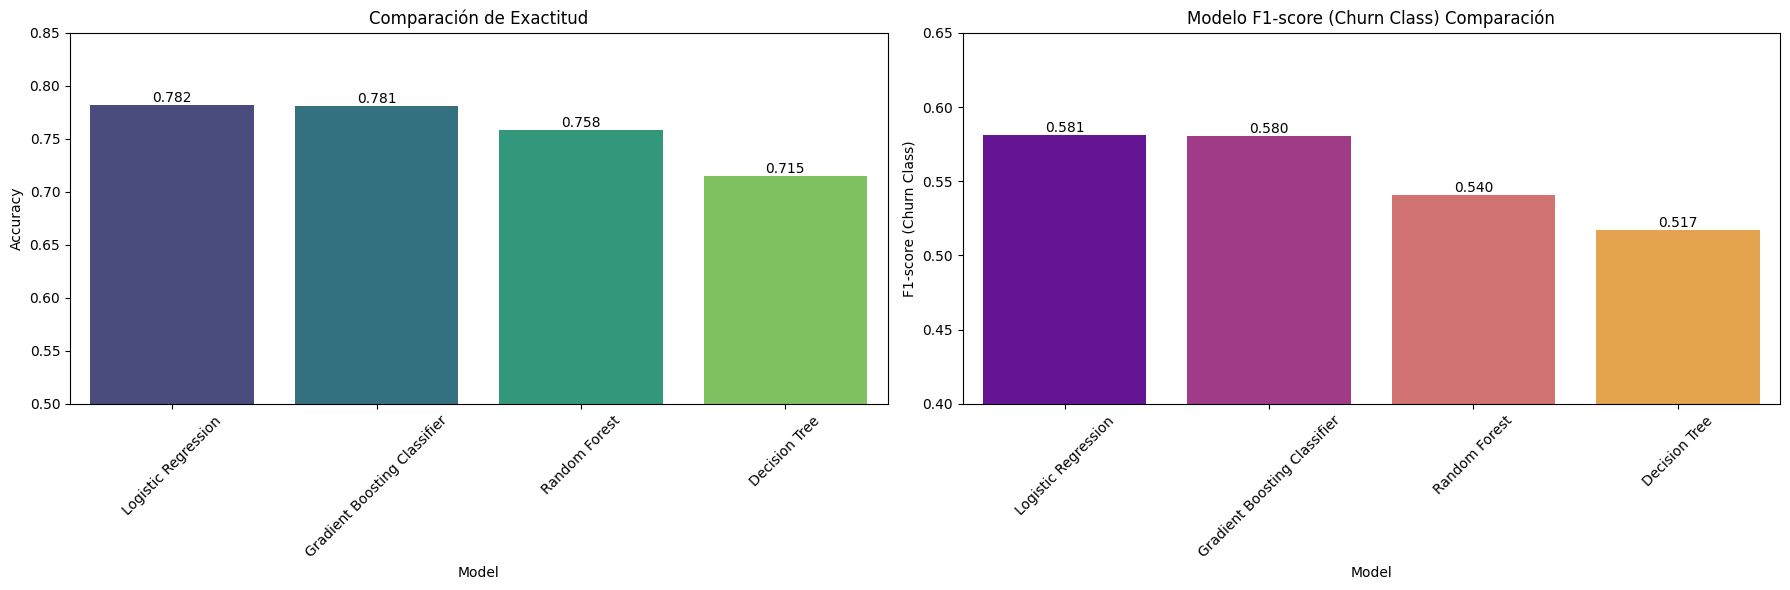

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# Bar plot for Exactitud
sns.barplot(x='Model', y='Accuracy', data=model_performance_sorted, ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Comparación de Exactitud')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0.5, 0.85)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f')

# Bar plot for F1-score (Churn Class)
sns.barplot(x='Model', y='F1-score (Churn Class)', data=model_performance_sorted, ax=axes[1], palette='plasma', hue='Model', legend=False)
axes[1].set_title('Modelo F1-score (Churn Class) Comparación')
axes[1].set_ylabel('F1-score (Churn Class)')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0.4, 0.65)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

# INFORME DE HALLAZGOS

#Contexto
---
La empresa Telecom X enfrentaba una alta tasa de abandono de clientes y necesitaba comprender los factores subyacentes que llevaban a los usuarios a cancelar sus servicios. Este análisis se llevó a cabo con el objetivo de identificar patrones críticos y razones del abandono de clientes, con un enfoque particular en los clientes en etapas tempranas (primeros 12 meses de contrato) y en segmentos demográficos específicos. Al examinar las tasas de abandono según la antigüedad del contrato, los perfiles demográficos (género, edad de tercera edad, estado civil y dependientes) y los comportamientos de consumo y costo de los servicios, el análisis proporcionó información valiosa para identificar segmentos de clientes en riesgo y desarrollar estrategias de retención dirigidas y efectivas.

# Limpieza, Tratamiento Y preparación de datasets para usar en los modelos
---
* Carga y Transformación: Se cargó el dataset base_ClientesTX.csv. Las columnas churn y genero fueron transformadas a tipos numéricos (int).
* Eliminación de Identificadores: La columna clienteID fue correctamente eliminada ya que es un identificador único y no aporta valor predictivo.
* Análisis Numérico: La matriz de correlación numérica reveló una alta correlación entre cargos_totales, cargos_mensuales y antiguedadContrato_Meses. Como cargos_totales y cargos_diarios estaban directamente derivados de otras columnas o tenían redundancia, fueron eliminados para evitar multicolinealidad y simplificar el modelo.
* Análisis Categórico (Chi-cuadrado): El test Chi-cuadrado nos permitió identificar telefono_suscripcion como una variable con una relación estadísticamente débil con la variable churn (alto p-value). Por lo tanto, fue eliminada del dataset.
* Normalización y Codificación: Las variables numéricas restantes fueron normalizadas usando MinMaxScaler, y las variables categóricas fueron codificadas mediante One-Hot Encoding para prepararlas para los modelos de Machine Learning.

# Selección de Modelos Predictivo, Conclusiones e Insights

**Se entrenaron y evaluaron cuatro modelos de clasificación:**
* Regresión Logística
* Random Forest
* Árbol de Decisión
* Gradient Boosting Classifier

####Resultados
**Regresión Logística**
Métricas Clave:
`Accuracy (Exactitud): 0.782
F1-score (Clase Churn - 1): 0.581
Precision (Clase Churn - 1): 0.65
Recall (Clase Churn - 1): 0.53`

**Random Forest**
`Accuracy (Exactitud): 0.758
F1-score (Clase Churn - 1): 0.540
Precision (Clase Churn - 1): 0.60
Recall (Clase Churn - 1): 0.49`

**Decision Tree**
`Accuracy (Exactitud): 0.715
F1-score (Clase Churn - 1): 0.517
Precision (Clase Churn - 1): 0.50
Recall (Clase Churn - 1): 0.53`

**Gradient Boosting Classifier**
`Accuracy (Exactitud): 0.781
F1-score (Clase Churn - 1): 0.580
Precision (Clase Churn - 1): 0.65
Recall (Clase Churn - 1): 0.53`

Regresión Logística: F1-score (Churn) de 0.581, Accuracy de 0.782. Fue el modelo con el mejor rendimiento en F1-score para la clase 'churn'.
Gradient Boosting Classifier: F1-score (Churn) de 0.580, Accuracy de 0.781. Muy cercano al Logistic Regression.
Random Forest: F1-score (Churn) de 0.540, Accuracy de 0.758.
Árbol de Decisión: F1-score (Churn) de 0.517, Accuracy de 0.715. Fue el de menor rendimiento.

Los gráficos de barras confirmaron visualmente que la Regresión Logística y el Gradient Boosting Classifier eran los modelos superiores en ambas métricas clave. Las matrices de confusión detallaron que todos los modelos eran muy buenos identificando a los clientes que no harían churn (altos True Negatives). Sin embargo, la Regresión Logística y Gradient Boosting lograron un mejor balance en identificar a los clientes que sí harían churn (True Positives) mientras mantenían los falsos positivos bajo control, lo que se refleja en su mejor F1-score.

####**`CONCLUSIÓN: `**
El ejercicio revela que, a pesar de la disponibilidad de modelos más complejos, la Regresión Logística y el Gradient Boosting Classifier fueron los más efectivos para predecir el churn en este conjunto de datos. Ambos modelos lograron un buen balance entre identificar correctamente a los clientes en riesgo (Verdaderos Positivos) y minimizar las falsas alarmas (Falsos Positivos), lo cual es crucial para una intervención eficiente en la retención de clientes.
Basándonos en la evaluación, especialmente priorizando el F1-score para la clase de churn, el modelo Logistic Regression emerge como el modelo campeón. Su capacidad para equilibrar la identificación de clientes que probablemente harán churn (recall) con la fiabilidad de esas predicciones (precision) es ligeramente superior en este caso, lo que lo hace el más adecuado para tomar acciones de retención de clientes. El Gradient Boosting Classifier es una alternativa muy cercana y también un excelente candidato.

### Recomendaciones

En base a la información sobre las características de los clientes que tienden a abandonar el servicio se hacen las siguientes recomendaciones

**Utilizar el Modelo Campeón para la Identificación Temprana.**
* El modelo mostró el mejor F1-score para la clase 'churn', lo que significa que es el más equilibrado en detectar a los clientes en riesgo y minimizar las falsas alarmas.

**Foco en la Antigüedad del Contrato y Nuevos Clientes:**

1. Desarrollar estrategias de fidelización específicas para clientes con baja antigüedad de contrato especialmente durante los primeros seis meses. Considerar paquetes de bienvenida, seguimiento proactivo o incentivos adicionales.
* El histograma de antigüedad del contrato mostró un pico significativo en los clientes más recientes, lo que sugiere que los primeros meses son un período crítico donde la tasa de churn puede ser más alta.
Revisar y Optimizar las Ofertas de Contrato y Métodos de Pago:

2. Analizar la percepción de valor de los tipos de contrato. Incentivar la adopción de pago automático y evaluar la satisfacción con los métodos de pago disponibles.
* Estas variables mostraron una alta significancia en el test Chi-cuadrado, indicando una fuerte relación con el churn.

** Promover y Mejorar Servicios de Valor Agregado:**

Reforzar la propuesta de valor de servicios como la seguridad online, backup online, protección de dispositivos, soporte técnico, TV digital y películas digitales.
* La suscripción a estos servicios influye significativamente en el churn, según el análisis Chi-cuadrado. Los clientes que perciben más valor en el ecosistema de servicios son menos propensos a irse. Identificar si hay deficiencias en estos servicios que puedan estar impulsando el churn.

** Diseñar campañas de comunicación y ofertas personalizadas para clientes de la tercera edad y aquellos que tienen dependientes.**
Estas variables también mostraron ser predictivas de churn, sugiriendo que estos segmentos pueden tener necesidades o sensibilidades distintas que requieren un enfoque adaptado.

** Mejorar la Experiencia del Usuario con Facturación y Soporte.**
Ambas variables son importantes predictoras de churn. Problemas con la facturación o un soporte técnico deficiente pueden ser puntos de fricción clave.

** Estrategias para Clientes sin Suscripción a Internet o Servicios Específicos:**

Evaluar el impacto del tipo_servicio_internet. Para clientes con 'SIN SUSCRIPCIÓN A INTERNET' o aquellos que no tienen internet_suscripcion, considerar ofertas que puedan aumentar su engagement o valorar si son segmentos de menor valor estratégico.
* La presencia y tipo de servicio de internet son variables influyentes.

Al implementar estas recomendaciones, la empresa podrá pasar de una reacción a una gestión proactiva del churn, optimizando los recursos y, en última instancia, mejorando la retención de clientes y la rentabilidad.
